### Figure 5

This code generates Figure 5 of the paper. This figure corresponds to analysis of A549 cells treated with 100nM dexamethasone <br>
<br>
INPUT:<br>
processed/ExpDecayConst_params.csv : Parameters for two-state model for each dataset<br>
processed/Compiled_accessible_target_ChIP_peaks.csv: Cumulative positional distribution of<br>
TF binding events
<br>
<br>
OUTPUT: <br>
Figure5B-C.pdf <br>




In [77]:
## Load required modules and functions
import os 
import pandas as pd
import numpy as np
from plotnine import *
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from math import exp,log
from scipy.stats import norm
os.chdir('/projects/b1042/AmaralLab/Maalavika/TF_Positional_Distribution_Model/scripts/Figure5')
from utils import *
import seaborn as sns
import patchworklib as pw
from random import choices
from statannot import add_stat_annotation
from sklearn.linear_model import LinearRegression
import math
from sklearn.metrics import *

#Set fontsize and point size for figures
font_size = 44
point_size = 6

#Set working directory
working_dir ="/projects/b1042/AmaralLab/Maalavika/TF_Positional_Distribution_Model/data/ENCODE/A549_Perturbation/ChIP-seq/"
os.chdir(working_dir)

## Load model parameters and peak data

In [44]:
#Load compiled peak distribution and parameters for each fit
params= pd.read_csv('processed/ExpDecayConst_params.csv', index_col =0)
df= pd.read_csv('processed/Compiled_accessible_target_ChIP_peaks.csv', index_col =0)

#Merge parameters for each cell line
df = df.merge(params,on=['TF','Treatment'])

#Reference annotation file
TSS_ref = pd.read_table('../../TF_TSS_10kb_named.bed')
TSS_ref['TSS'] = TSS_ref.end - 10000

## Classification of target genes as true and spurious

In [70]:
#Initialize compiled gene classification
compiled_summary = pd.DataFrame()

#Loop through treatment and atac conditions
treatments = ['control','dexamethasone']

cutoffs_compiled= pd.DataFrame()


for idx, treatment in enumerate(treatments):
    tfs= os.listdir(treatment)
    for tf in tfs:
        if any(tf  == params.TF):
            #Load files
            df =  pd.read_table(treatment +'/'+tf + '/'+ treatment + '_consensuspeaks_accessible_'+treatment+'_named.bed',
                                     names = ['chrom','start','end','Gene' ])
            df = df.drop_duplicates()

            #Get distance of peak from TSS
            df=df.merge(TSS_ref[['TSS','Gene']])
            df['start_diff'] =  df['start'] - df['TSS']
            df['end_diff'] =  df['end'] - df['TSS']
            df['min_dist'] = df.apply(lambda x: abs(sum([x['start_diff'], x['end_diff']])/2), axis =1)

            #Extract params for condition
            params_sub = params.loc[(params.TF == tf) & (params.Treatment == treatment)]

            #Classify genes as true and spurious
            #for val in np.linspace(1,3,5): 
            thresholds = [0.001,0.01,0.05,0.1, 0.2,0.3,0.4,0.5,0.7]
            threshold_cutoffs =  n_max_true(params_sub.rb.values[0],
                                            params_sub.tau.values[0],
                                            params_sub.rs.values[0], thresholds)
            for idx,val in threshold_cutoffs.iterrows():
                df['Binding_' + str(thresholds[idx])] = df.min_dist <= val['Distance']

            #Compile threhsold cutoffs
            threshold_cutoffs['TF'] = tf
            threshold_cutoffs['Treatment'] = treatment
            cutoffs_compiled= pd.concat([threshold_cutoffs, cutoffs_compiled])


            binding_cols = [i for i in df.columns if 'Binding_' in i]
            #Select genes with true binding
            genes_summary = df.groupby('Gene').apply(lambda x: (x[binding_cols]==True).any())
            #Genes with all spurious binding
            genes_summary_sp = df.groupby('Gene').apply(lambda x: (x[binding_cols]==False).all())
            #Remove intermediate genes
            genes_summary =genes_summary.loc[(genes_summary.any(axis=1)) | (genes_summary_sp.all(axis=1)) ]


            genes_summary['TF'] = tf
            genes_summary['Treatment'] = treatment


            #Compile across datasets
            compiled_summary = pd.concat([compiled_summary,genes_summary])


compiled_summary.to_csv('processed/CompiledGeneClassification_multipleThresholds.csv')

In [71]:
## Reformat and pivot data
compiled_threshold = pd.DataFrame()
for threshold in compiled_summary.columns[:-2]:
    compiled = compiled_summary.reset_index().pivot(index=['Gene','TF'], columns='Treatment', values= threshold).reset_index().drop_duplicates()
    compiled['Threshold'] = threshold.split('_')[1]
    compiled_threshold = pd.concat([compiled_threshold, compiled])

## Load and process RNA-seq data

In [72]:
## Get RNA counts (From original analysis)
rna = pd.read_csv('../RNA-seq/processed/A549_dex12h_RNAseq_counts.csv', index_col = 0)

## Calculate Log2FC
control_cols = [i for i in rna.columns if 'control' in i]
dex_cols = [i for i in rna.columns if 'dexamethasone' in i]
rna['log2FC'] = np.log2((rna[dex_cols].mean(axis=1) +1) /(rna[control_cols].mean(axis=1) +1))

## Assign labels to each gene 

In [73]:
compiled_threshold['Class'] = "Expected/Predicted"
compiled_threshold['Class'].loc[compiled_threshold.control == compiled_threshold.dexamethasone] = "NotExpected/NotPredicted"

compiled_threshold['Class'].loc[((compiled_threshold.control.isna())& (compiled_threshold.dexamethasone == False))|
                                ((compiled_threshold.dexamethasone.isna())& (compiled_threshold.control== False))] = "Expected/NotPredicted"

compiled_threshold['Class'].loc[((compiled_threshold.control == True) & (compiled_threshold.dexamethasone == False))|
                                ((compiled_threshold.dexamethasone == True) & (compiled_threshold.control == False))] = "NotExpected/Predicted"


## Identify Not expected/Not predicted genes across all TFs
NENF = compiled_threshold.groupby(['Gene']).apply(lambda x: x if all(x.Class =='NotExpected/NotPredicted') else None)
NENF_Gene = NENF.Gene.unique()

#Genes with exp data but no binding

rna_genes = rna.loc[~rna.index.isin(compiled_threshold.Gene)].index
NENF_Gene = list(NENF_Gene)+ list(rna_genes)



## Plot Figure 5B and 5C

In [82]:
ax =[]
col = sns.color_palette("colorblind",4).as_hex()

#Test effect on group size for varying thresholds
compiled_rna_threshold = pd.DataFrame()
for threshold in compiled_threshold.Threshold.unique():
    
    #Subset interactions for threshold
    compiled = compiled_threshold.loc[compiled_threshold.Threshold == threshold]
    
    #Get Expected/Not Predicted genes for threshold
    ENF = compiled.groupby(['Gene']).apply(lambda x: x if all(x.Class =='Expected/NotPredicted') else None)
    
    if not ENF.empty:
        ENF_Gene = ENF.Gene.unique()

        compiled = compiled.loc[compiled.TF=='BCL3']
        compiled = compiled.loc[compiled.Class.isin(['Expected/Predicted','NotExpected/Predicted' ])]
        genes_all = compiled.Gene.unique()

        #Subset mRNA expression for target genes
        rna_sub = rna.loc[rna.index.isin(genes_all)]
        rna_sub['Gene'] = rna_sub.index
        compiled_rna = rna_sub.merge(compiled[['Gene','Class']], on = 'Gene', how = 'left')

        #Add NENF/ENF genes
        rna_NENF = rna.loc[rna.index.isin(NENF_Gene)]
        rna_NENF['Class'] = "NotExpected/NotPredicted"
        rna_NENF['Gene'] = rna_NENF.index
        rna_ENF = rna.loc[rna.index.isin(ENF_Gene)]
        rna_ENF['Class'] = "Expected/NotPredicted"
        rna_ENF['Gene'] = rna_ENF.index

        #compile all classes
        compiled_rna = pd.concat([compiled_rna,rna_NENF])
        compiled_rna = pd.concat([compiled_rna,rna_ENF])
        
        
        #Compile data for each threshold
        compiled_rna.Class = pd.Categorical(compiled_rna.Class , 
                                             ['NotExpected/NotPredicted','Expected/NotPredicted',
                                              'Expected/Predicted', 'NotExpected/Predicted'])
        labels = ['NotExpected/NotPredicted','Expected/NotPredicted',
                                              'Expected/Predicted', 'NotExpected/Predicted']
        compiled_rna['log2FC (abs)'] = np.abs(compiled_rna['log2FC'])


        #compile all RNA data
        compiled_rna['Threshold'] = threshold
        compiled_rna_threshold = pd.concat([compiled_rna_threshold,compiled_rna])
    
        #Plot Figure 5C for threshold of 0.05 (threshold for identifying 95% biologically relevant binding events
        if threshold == '0.05':

            compiled_rna = compiled_rna.loc[compiled_rna.Class.isin(labels)]
            compiled_rna.Class =[i.replace("/","\n"  ) for i in compiled_rna.Class]
            compiled_rna.Class = pd.Categorical(compiled_rna.Class , 
                                             ['NotExpected\nNotPredicted','Expected\nNotPredicted',
                                              'Expected\nPredicted', 'NotExpected\nPredicted'])
            labels =[i.replace("/","\n"  ) for i in labels]

            #PLOT
            fig5C = pw.Brick(figsize=(8,6))

            sns.violinplot(data=compiled_rna,x= 'Class',y = 'log2FC (abs)',
                           ax=fig5C,fontsize =24, palette =col)

            fig5C.set(
                xlabel='\n', 
                ylabel='|log2FC|\n',
                title= "Threshold = " + str(threshold) 
            )

            fig5C.tick_params(labelsize=24)
            fig5C.set_ylabel(fig5C.get_ylabel(),fontsize = 24)
            fig5C.set_title(fig5C.get_title(),fontsize = 24)
            fig5C.spines[['left','bottom']].set_linewidth(2) 
            fig5C.spines[['top','right']].set_linewidth(0) 

            #Add sample size
            x_labels_n = compiled_rna.groupby('Class').size().reset_index(name = 'Size')
            x_labels_n['NewLabel'] = x_labels_n['Class'].astype(str)+ '\n(n = ' + x_labels_n['Size'].astype(str) + ')'
            fig5C.set_xticklabels(x_labels_n['NewLabel'])


            fig5C, test_results = add_stat_annotation(fig5C,data=compiled_rna.loc[compiled_rna.Class.isin(labels)],
                                                    x= 'Class',y = 'log2FC (abs)',
                                               box_pairs=[(labels[0], labels[1]), 
                                                         (labels[0], labels[3]),
                                                         (labels[2], labels[1]),
                                                         (labels[2], labels[3]),
                                                         (labels[1], labels[3])],
                                               line_offset_to_box=0.1, line_offset=0, 
                                                fontsize=24,line_height=0.01, text_offset=2,
                                              test='Mann-Whitney', text_format='star', loc='inside', verbose=2)

p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

NotExpected
NotPredicted v.s. Expected
NotPredicted: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=8.913e-11 U_stat=6.654e+07
Expected
NotPredicted v.s. Expected
Predicted: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.079e-133 U_stat=8.548e+05
Expected
Predicted v.s. NotExpected
Predicted: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.610e-04 U_stat=3.026e+05
Expected
NotPredicted v.s. NotExpected
Predicted: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.653e-268 U_stat=1.148e+06
NotExpected
NotPredicted v.s. NotExpected
Predicted: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=0.000e+00 U_stat=4.358e+06


<Figure size 432x288 with 0 Axes>

In [84]:

#Reformat data to get sizes of groups for each threhsold level
compiled_thresh_size = compiled_rna_threshold.groupby(['Threshold','Class']).size().reset_index(name='Size')
compiled_thresh_size.Threshold = compiled_thresh_size.Threshold.astype(float)

## Plot Figure 5B
fig5B = (ggplot(compiled_thresh_size)
+geom_line(aes(x='Threshold',y='Size',group='Class',color = "Class"),size= 3, show_legend=False)
+theme_classic()
+theme(text=element_text(size=font_size), axis_text = element_text(size=32),
           axis_line_x=element_line(linewidth=2),axis_line_y=element_line(linewidth=2))
+ylab('Number of Genes')
+scale_color_manual(values = col)
+scale_y_log10())

fig5B =  pw.load_ggplot(fig5B, figsize=(8,6))




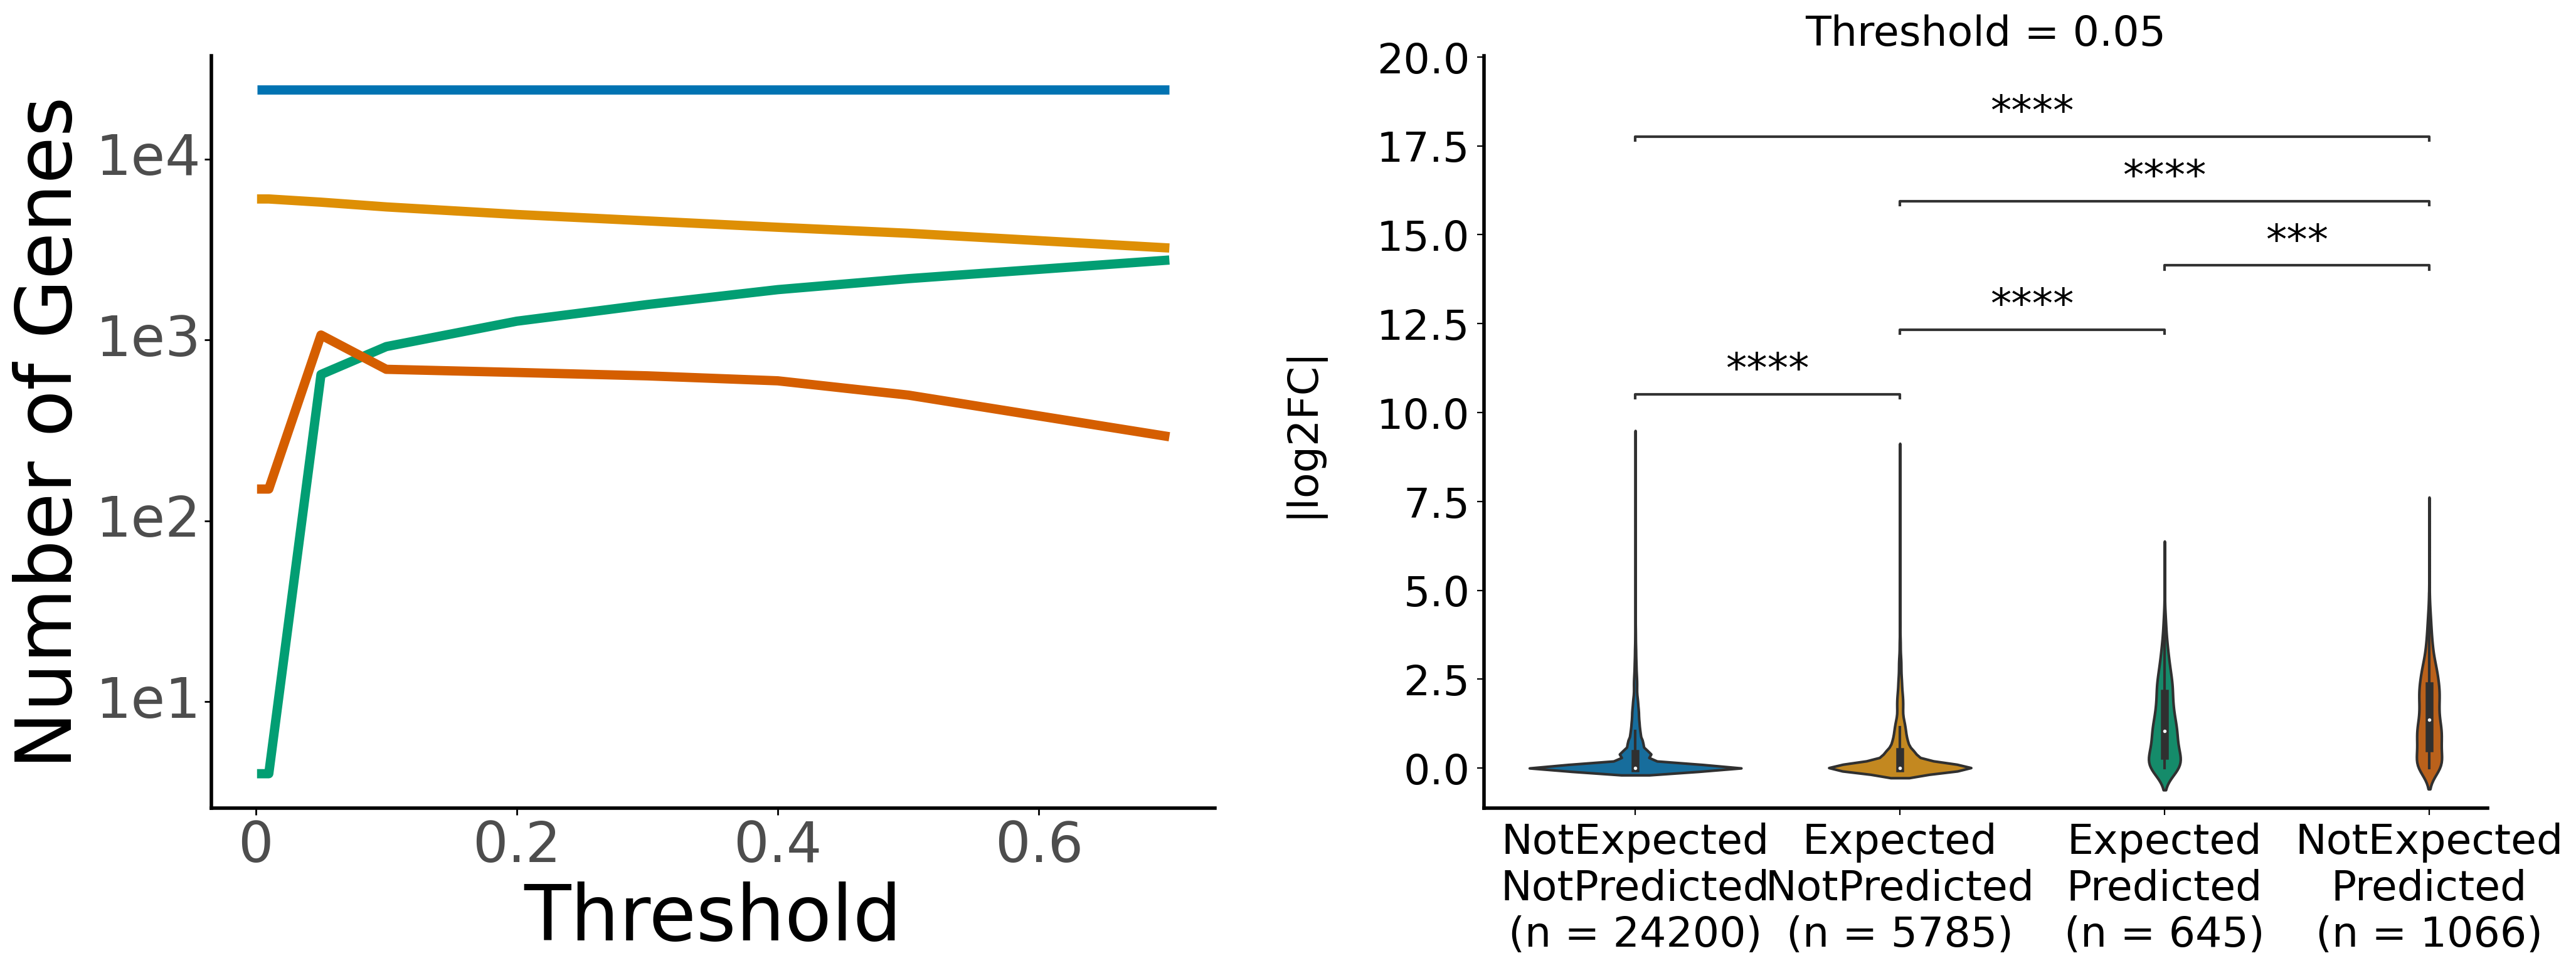

In [85]:
fig5B + fig5C